# Labyrinth Camera Observation Viewer

This notebook lets you **see through the eyes of the Crazyflie drone** as it flies through a procedurally generated labyrinth.

### What you'll see
1. **Raw camera output** — the 64x64 RGBA image from the simulated HM01B0 camera sensor
2. **Grayscale conversion** — how the image is processed before the neural network sees it
3. **Frame stacking** — 4 consecutive frames stacked together to give the agent a sense of motion
4. **Observation anatomy** — the full breakdown of what the actor (policy) and critic (value function) receive
5. **Trajectory visualization** — the drone's path through the labyrinth with camera thumbnails

### Architecture context
We use **asymmetric actor-critic**: the actor only sees camera images + basic IMU data (velocity, orientation, goal direction), while the critic gets privileged information (exact distances, obstacle proximity) that wouldn't be available on a real drone.

### Requirements
- Run in the `isaaclab` conda environment
- Do NOT call `simulation_app.close()` in a notebook — it crashes the kernel. Just restart the kernel to re-run.

In [ ]:
# Jupyter requires nest_asyncio to handle Isaac Sim's internal async event loops.
# This MUST run before any Isaac Sim imports.
import nest_asyncio
nest_asyncio.apply()

## Step 1: Launch the Simulator

Isaac Sim is NVIDIA's physics simulator. We launch it in **headless mode** (no GUI window) with camera rendering enabled. This must happen before importing any Isaac Lab modules — the simulator initializes GPU resources that everything else depends on.

> This cell takes 15-30 seconds on first run while the simulator loads.

In [2]:
# Cell 1: Launch Isaac Sim via AppLauncher (MUST be the first code cell)
# AppLauncher configures asset paths, camera rendering, etc. that bare SimulationApp does not.
import argparse
from isaaclab.app import AppLauncher

args = argparse.Namespace(
    headless=True,
    enable_cameras=True,
    device="cuda:0",
    experience="",
    livestream=-1,
    verbose=False,
    width=1280,
    height=720,
)
app_launcher = AppLauncher(args)
simulation_app = app_launcher.app
print("Isaac Sim launched successfully.")

[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: C:\Users\alesm\Documents\IsaacLab\apps\isaaclab.python.headless.rendering.kit


## Step 2: Create the Environment

Now we create the labyrinth environment with a single drone. Key configuration:

- **1 environment** (we only need one for visualization)
- **64x64 camera** mounted on the drone body, pointing forward
- **4-frame stack** — the policy sees the last 4 grayscale frames stacked together, giving it temporal context (like seeing motion)

The observation space is `12 + 4*64*64 = 16,396` dimensional:
- **12 proprio values**: linear velocity (3), angular velocity (3), gravity direction (3), goal offset (3)
- **16,384 pixel values**: 4 frames x 64x64 grayscale

In [3]:
# Cell 2: Imports & environment setup (all Isaac/Omniverse imports MUST come after SimulationApp)
import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

%matplotlib inline

import isaac_robots.tasks  # register all Gymnasium envs

from isaac_robots.tasks.direct.isaac_labyrinth.isaac_labyrinth_env_cfg import LabyrinthEnvCfg
from isaac_robots.tasks.direct.isaac_labyrinth.cfg import CRAZYFLIE_AI_CAMERA_64_CFG

# Build environment config: 1 env, camera enabled
env_cfg = LabyrinthEnvCfg()
env_cfg.scene.num_envs = 1
env_cfg.camera = CRAZYFLIE_AI_CAMERA_64_CFG.replace(
    prim_path="/World/envs/env_.*/Robot/body/ai_camera"
)
# Recompute obs space for camera mode: proprio(12) + stacked frames(4*64*64)
env_cfg.observation_space = 12 + env_cfg.frame_stack * env_cfg.camera.height * env_cfg.camera.width

env = gym.make("Isaac-Robots-Labyrinth-Direct-v0", cfg=env_cfg)
uw = env.unwrapped  # direct access to LabyrinthDirectEnv internals

print(f"Environment created: {env.spec.id}")
print(f"  Observation space: {env.observation_space.shape}")
print(f"  Action space:      {env.action_space.shape}")
print(f"  Camera:            {env_cfg.camera.width}x{env_cfg.camera.height}")
print(f"  Frame stack:       {env_cfg.frame_stack}")
print(f"  Num envs:          {env_cfg.scene.num_envs}")

## Step 3: Run an Episode and Collect Data

We run the drone for 200 physics steps using **random actions** (no trained policy). At each step we capture:

- **Raw RGBA** — the 4-channel image straight from the camera sensor (what a real camera would output)
- **Grayscale** — the processed single-channel image (what the neural network actually receives)
- **Frame stack** — the buffer of 4 most recent grayscale frames
- **Position & reward** — for trajectory visualization later

The drone will tumble around randomly — that's fine! We just want to see what the camera captures.

In [4]:
# Cell 3: Run episode & collect frames
obs, info = env.reset()

N_STEPS = 200

rgba_frames = []    # raw RGBA: (H, W, 4) uint8
gray_frames = []    # grayscale: (H, W) float [0,1]
stack_snapshots = [] # frame buffer: (4, H, W) float
positions = []      # world position: (3,)
reward_list = []

for step in range(N_STEPS):
    # Random actions with slight upward thrust to keep drone airborne
    action = torch.randn(1, 4, device=uw.device) * 0.3
    action[0, 0] = 0.2  # gentle positive thrust
    obs, reward, terminated, truncated, info = env.step(action)

    # Raw RGBA from TiledCamera sensor
    rgba = uw._camera.data.output["rgb"][0].cpu().numpy()  # (H, W, 4) uint8
    rgba_frames.append(rgba)

    # Grayscale conversion (same formula as _get_observations)
    gray = (0.299 * rgba[..., 0].astype(np.float32)
          + 0.587 * rgba[..., 1].astype(np.float32)
          + 0.114 * rgba[..., 2].astype(np.float32)) / 255.0
    gray_frames.append(gray)

    # Frame stack buffer snapshot
    if uw._frame_buffer is not None:
        stack_snapshots.append(uw._frame_buffer[0].cpu().numpy().copy())

    # Drone world position
    positions.append(uw._robot.data.root_pos_w[0].cpu().numpy().copy())
    reward_list.append(float(reward.cpu()) if torch.is_tensor(reward) else float(reward))

    # Reset if episode ends
    if terminated or truncated:
        obs, info = env.reset()

# Convert to numpy arrays
rgba_frames = np.stack(rgba_frames)       # (T, H, W, 4)
gray_frames = np.stack(gray_frames)       # (T, H, W)
stack_snapshots = np.stack(stack_snapshots) if stack_snapshots else None  # (T, 4, H, W)
positions = np.stack(positions)           # (T, 3)
rewards = np.array(reward_list)           # (T,)

print(f"Collected {N_STEPS} steps")
print(f"  RGBA frames:  {rgba_frames.shape} {rgba_frames.dtype}")
print(f"  Gray frames:  {gray_frames.shape}")
print(f"  Frame stacks: {stack_snapshots.shape if stack_snapshots is not None else 'N/A'}")
print(f"  Positions:    {positions.shape}")
print(f"  Reward range: [{rewards.min():.4f}, {rewards.max():.4f}]")

## Step 4: Raw Camera Output vs Processed Observation

The drone's camera (simulating a real Himax HM01B0) outputs a **64x64 RGBA image** — 4 channels: Red, Green, Blue, Alpha.

Before feeding it to the neural network, we convert it to **grayscale** using standard luminance weights:
```
gray = 0.299*R + 0.587*G + 0.114*B
```
This matches how the human eye perceives brightness (green contributes most). The result is normalized to [0, 1].

This reduces each frame from 4 channels to 1 channel — a 4x data reduction that helps the CNN learn faster.

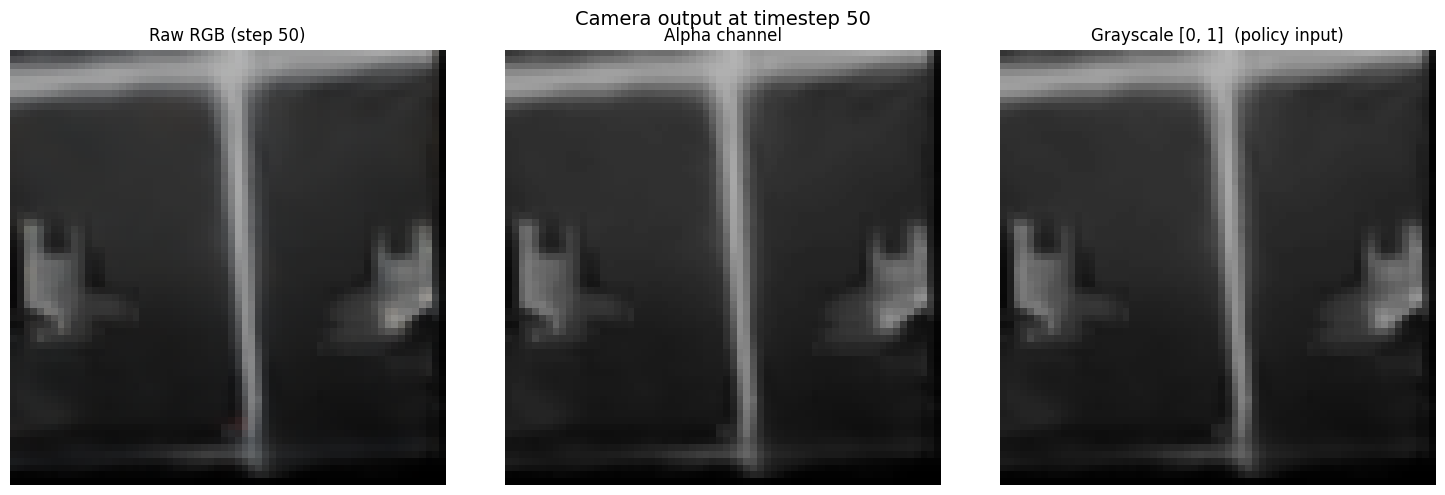

In [6]:
# Cell 4: Single frame — RGBA vs Grayscale
TIMESTEP = min(50, N_STEPS - 1)  # pick a mid-episode frame

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Raw RGBA (show RGB channels, drop alpha)
axes[0].imshow(rgba_frames[TIMESTEP, :, :, :3])
axes[0].set_title(f"Raw RGB (step {TIMESTEP})")
axes[0].axis("off")

# Alpha channel
axes[1].imshow(rgba_frames[TIMESTEP, :, :, 2], cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Alpha channel")
axes[1].axis("off")

# Processed grayscale (what the policy sees)
axes[2].imshow(gray_frames[TIMESTEP], cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Grayscale [0, 1]  (policy input)")
axes[2].axis("off")

plt.suptitle(f"Camera output at timestep {TIMESTEP}", fontsize=14)
plt.tight_layout()
plt.show()

## Step 5: Frame Stacking — Giving the Agent a Sense of Motion

A single image is a snapshot — it tells the agent *where* things are, but not *how they're moving*. By stacking 4 consecutive frames together, the agent can perceive motion (like optical flow).

This is the same technique used in the original **Atari DQN paper** (Mnih et al., 2015).

**What to look for:**
- At **t=0** (right after reset): all 4 frames are black — the agent has no history yet
- At **t=3**: 3 frames have filled in, 1 is still black
- At **t=10+**: all 4 frames show the scene, each slightly different as the drone moves

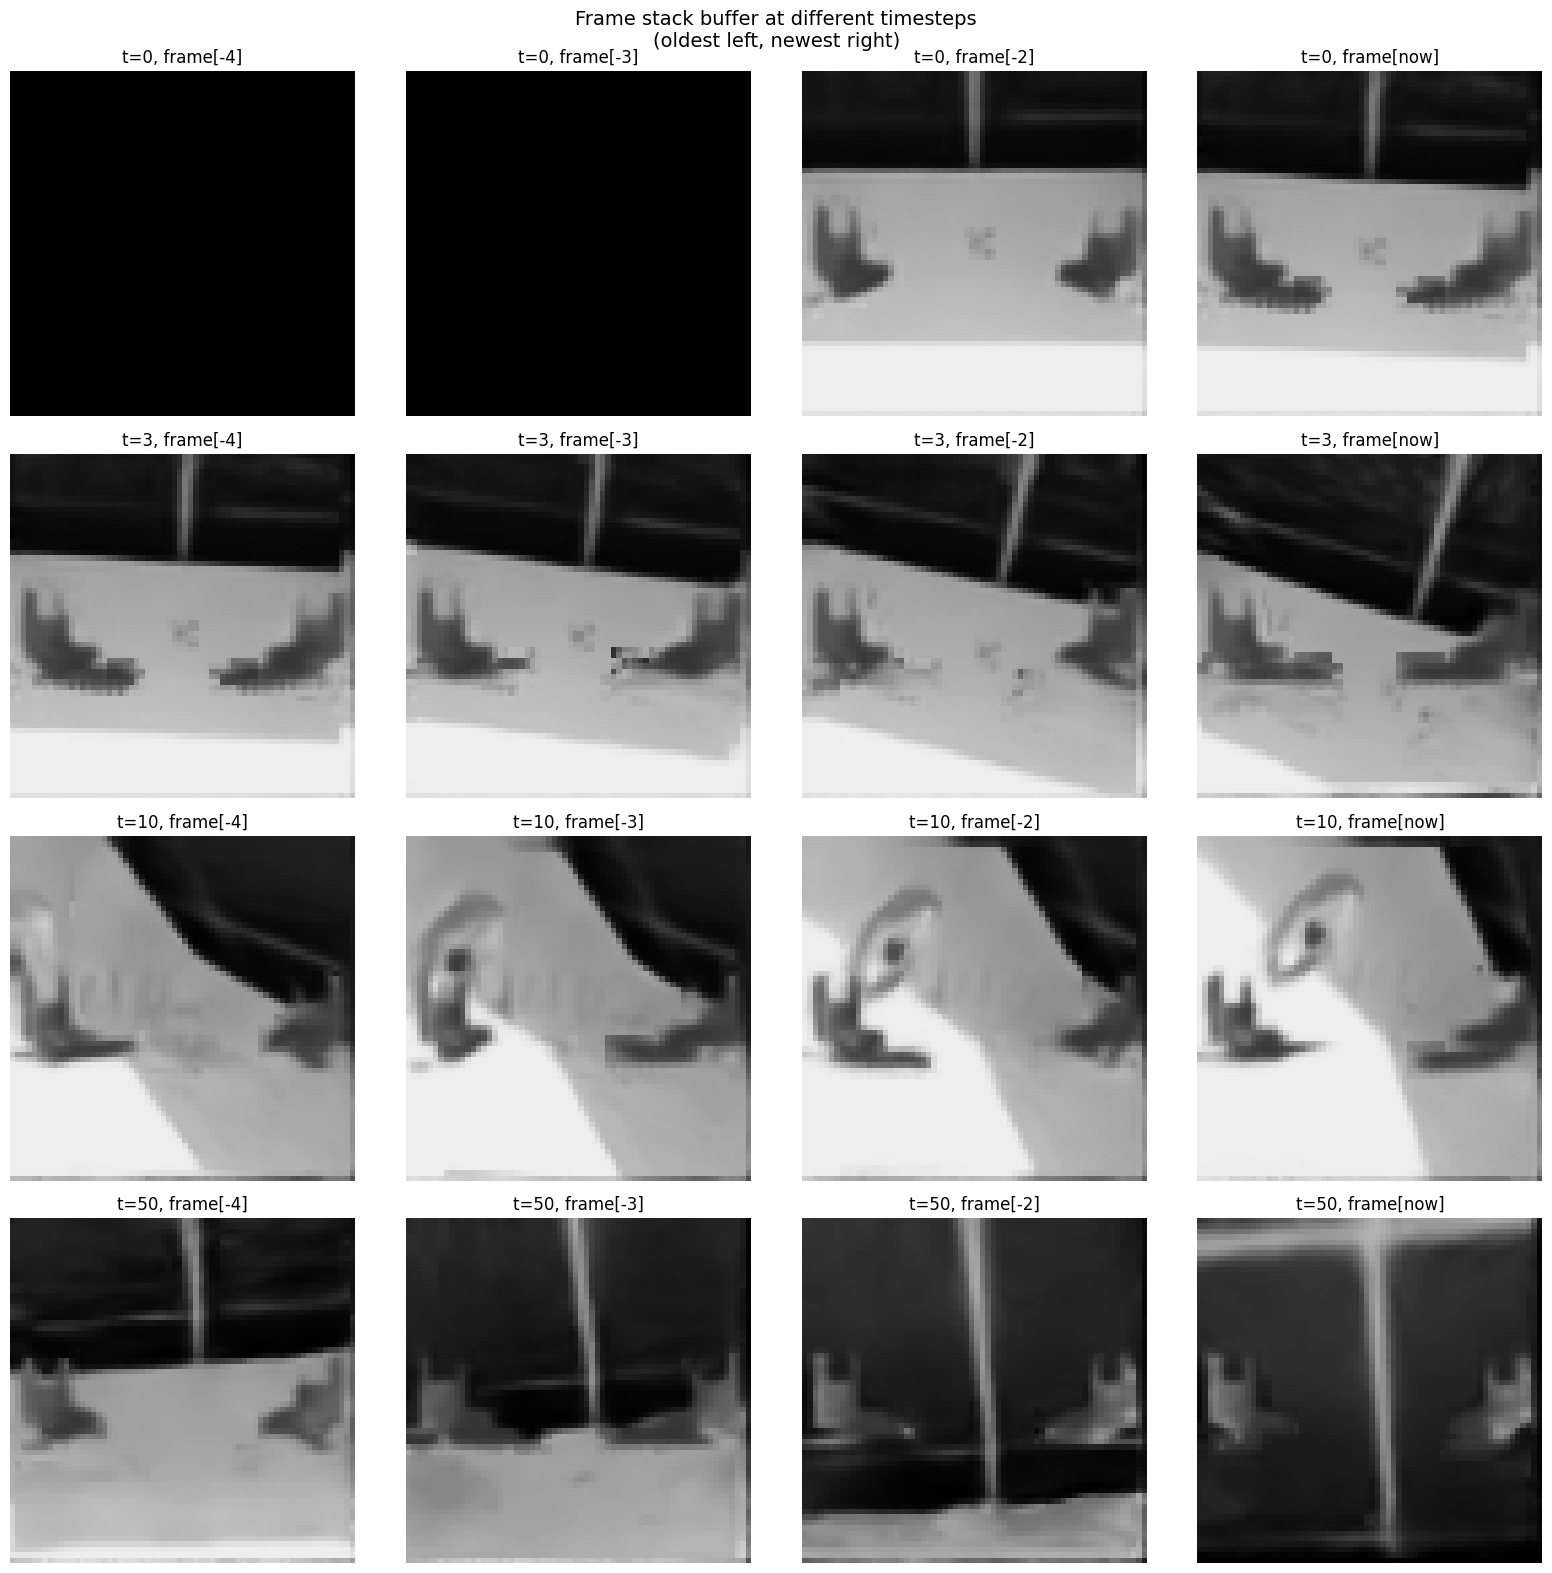

In [7]:
# Cell 5: Frame stack at multiple timesteps
if stack_snapshots is not None:
    sample_steps = [0, 3, 10, TIMESTEP]  # early (mostly black) → mid-episode
    sample_steps = [s for s in sample_steps if s < N_STEPS]

    fig, axes = plt.subplots(len(sample_steps), 4, figsize=(16, 4 * len(sample_steps)))
    if len(sample_steps) == 1:
        axes = axes[np.newaxis, :]

    for row, t in enumerate(sample_steps):
        for col in range(4):
            axes[row, col].imshow(stack_snapshots[t, col], cmap="gray", vmin=0, vmax=1)
            axes[row, col].set_title(f"t={t}, frame[-{4 - col}]" if col < 3 else f"t={t}, frame[now]")
            axes[row, col].axis("off")

    plt.suptitle("Frame stack buffer at different timesteps\n(oldest left, newest right)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Frame buffer not available (camera may not be enabled).")

## Step 6: Episode Filmstrip

A "filmstrip" showing every 10th camera frame across the full episode. This gives a quick overview of what the drone saw as it flew (or tumbled) through the labyrinth.

Read left-to-right to follow the drone's journey through time.

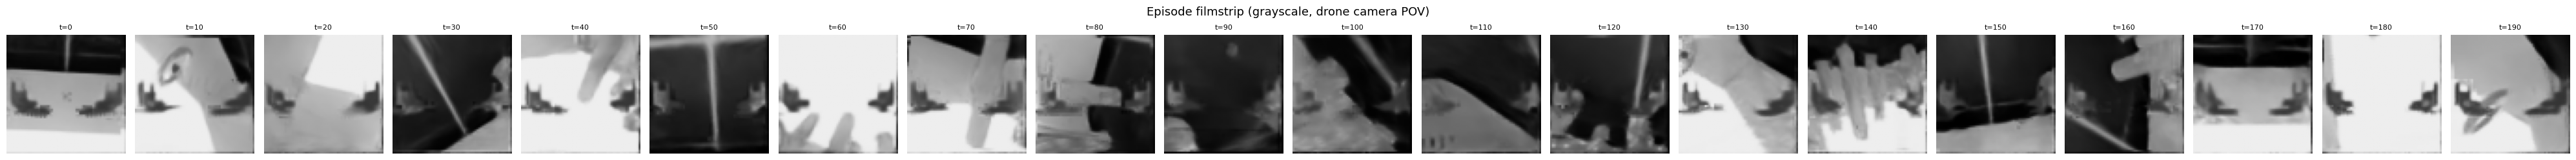

In [8]:
# Cell 6: Filmstrip — every Nth frame
EVERY_N = max(1, N_STEPS // 20)  # ~20 frames in the strip
indices = list(range(0, N_STEPS, EVERY_N))
n_frames = len(indices)

fig, axes = plt.subplots(1, n_frames, figsize=(2 * n_frames, 2.5))
if n_frames == 1:
    axes = [axes]

for ax, idx in zip(axes, indices):
    ax.imshow(gray_frames[idx], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"t={idx}", fontsize=8)
    ax.axis("off")

plt.suptitle("Episode filmstrip (grayscale, drone camera POV)", fontsize=13)
plt.tight_layout()
plt.show()

## Step 7: Animated Playback

Watch the full episode as an animation — this is exactly what the drone's camera sees at each timestep. The reward value is shown in the title so you can see when the drone is making progress (positive reward) vs crashing or drifting (negative reward).

Use the play/pause controls below the animation.

In [9]:
# Cell 7: Animated episode (inline video)
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(gray_frames[0], cmap="gray", vmin=0, vmax=1)
title = ax.set_title("t=0")
ax.axis("off")

def update(frame_idx):
    im.set_data(gray_frames[frame_idx])
    title.set_text(f"t={frame_idx}  |  reward={rewards[frame_idx]:.3f}")
    return [im, title]

anim = animation.FuncAnimation(fig, update, frames=N_STEPS, interval=50, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

## Step 8: Observation Anatomy — What the Networks Actually See

Our architecture uses **asymmetric actor-critic**, meaning the actor and critic receive *different* observations:

### Actor (policy network) — decides what to do
The actor gets what a real drone could measure:
- **Proprio (12D)**: IMU-like readings — velocity, angular rate, gravity direction, goal offset
- **Stacked frames (4x64x64)**: last 4 camera images, processed by a NatureCNN

### Critic (value network) — estimates how good the current situation is
The critic gets **privileged information** not available on a real drone:
- Goal offset in body frame (3D)
- Velocity and angular velocity (6D)
- **Geodesic distance** to goal (1D) — shortest path distance through the maze
- **Nearest obstacle distance** (1D) — from LiDAR

This asymmetry helps training converge much faster: the critic can accurately judge situations using "god mode" information, while the actor learns to achieve the same outcomes using only onboard sensors.

In [ ]:
# Cell 8: Observation anatomy — proprio bar chart + frame grid + critic state
obs_dict = obs  # last obs from the collection loop
if isinstance(obs_dict, dict):
    policy_obs = obs_dict["policy"][0].cpu().numpy() if "policy" in obs_dict else None
    critic_obs = obs_dict.get("critic", [None])[0]
    if critic_obs is not None:
        critic_obs = critic_obs.cpu().numpy()
else:
    policy_obs = obs_dict[0].cpu().numpy() if torch.is_tensor(obs_dict) else obs_dict
    critic_obs = None

# ── Actor observation breakdown ──────────────────────────────────────────
if policy_obs is not None and len(policy_obs) > 12:
    proprio = policy_obs[:12]
    labels = [
        "lin_vel_x", "lin_vel_y", "lin_vel_z",
        "ang_vel_x", "ang_vel_y", "ang_vel_z",
        "gravity_x", "gravity_y", "gravity_z",
        "goal_x", "goal_y", "goal_z",
    ]
    group_colors = (["#4C72B0"] * 3    # linear velocity — blue
                  + ["#DD8452"] * 3    # angular velocity — orange
                  + ["#55A868"] * 3    # gravity — green
                  + ["#C44E52"] * 3)   # goal offset — red

    # Proprio bar chart (standalone, clean)
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(range(12), proprio, color=group_colors)
    ax.set_yticks(range(12))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_title("Actor: Proprio vector (12D)\n"
                 "Blue=lin_vel  Orange=ang_vel  Green=gravity  Red=goal_offset")
    ax.invert_yaxis()
    ax.axvline(0, color="black", lw=0.5)
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

    # Stacked frames grid (standalone, 1 row of 4)
    img_flat = policy_obs[12:]
    n_pixels = 64 * 64
    fig, axes_img = plt.subplots(1, 4, figsize=(16, 4))
    for i in range(4):
        frame = img_flat[i * n_pixels : (i + 1) * n_pixels].reshape(64, 64)
        axes_img[i].imshow(frame, cmap="gray", vmin=0, vmax=1)
        age = f"t-{3-i}" if i < 3 else "t (now)"
        axes_img[i].set_title(f"Frame {i}: {age}", fontsize=11)
        axes_img[i].axis("off")
    plt.suptitle("Actor: Stacked camera frames (4 x 64x64)", fontsize=14)
    plt.tight_layout()
    plt.show()

# ── Critic privileged state breakdown ────────────────────────────────────
if critic_obs is not None:
    critic_labels = [
        "goal_x (body)", "goal_y (body)", "goal_z (body)",
        "lin_vel_x", "lin_vel_y", "lin_vel_z",
        "ang_vel_x", "ang_vel_y", "ang_vel_z",
        "geodesic_dist", "min_obstacle_dist",
    ]
    c_colors = (["#C44E52"] * 3    # goal offset — red
              + ["#4C72B0"] * 3    # linear velocity — blue
              + ["#DD8452"] * 3    # angular velocity — orange
              + ["#8172B3"] * 1    # geodesic — purple
              + ["#937860"] * 1)   # obstacle — brown

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(range(11), critic_obs, color=c_colors)
    ax.set_yticks(range(11))
    ax.set_yticklabels(critic_labels, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_title("Critic: Privileged state (11D) — NOT visible to actor\n"
                 "Red=goal  Blue=vel  Orange=ang_vel  Purple=geodesic  Brown=obstacle")
    ax.invert_yaxis()
    ax.axvline(0, color="black", lw=0.5)
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

## Step 9: Drone Trajectory & Rewards

**Left plot**: Bird's-eye view of the drone's path through the labyrinth. Color indicates time (dark=early, bright=late). Red stars show the waypoints the drone is trying to reach.

**Right plot**: Reward signal over time. Positive reward means the drone is making progress toward the goal; negative means it's drifting, tilting, or crashing.

**Bottom plot**: Altitude over time — you can see if the drone is maintaining height or falling.

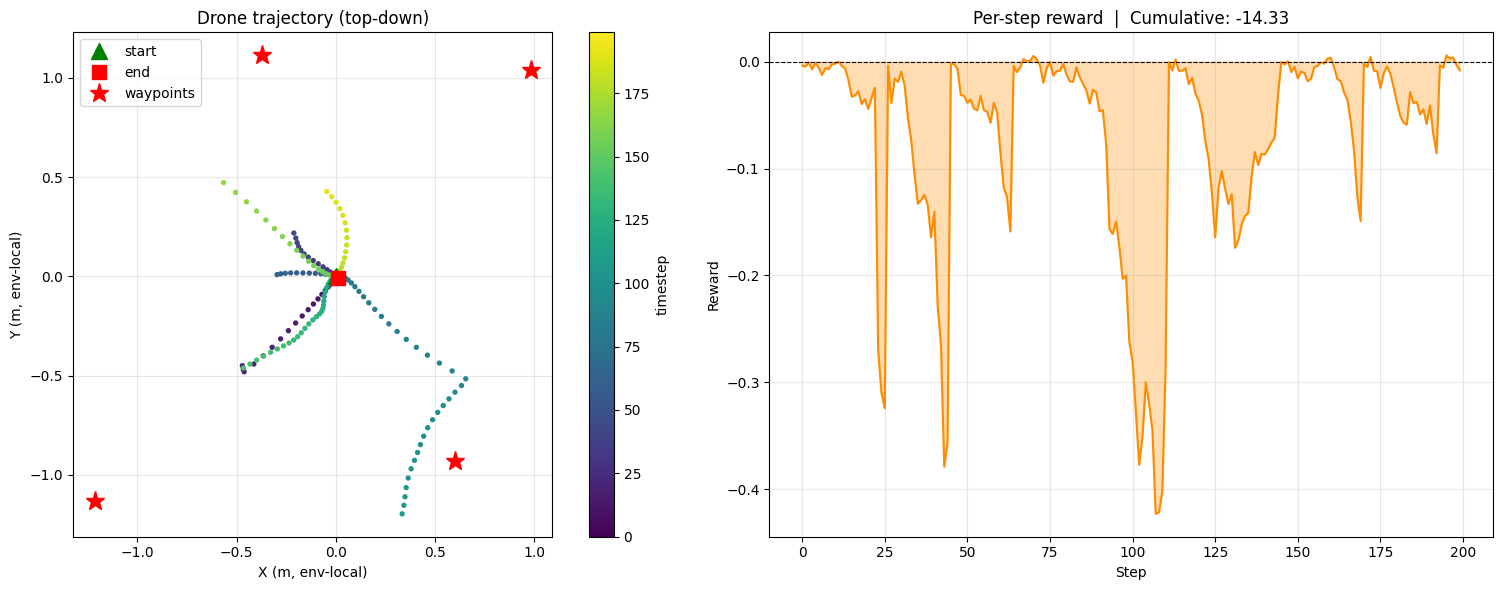

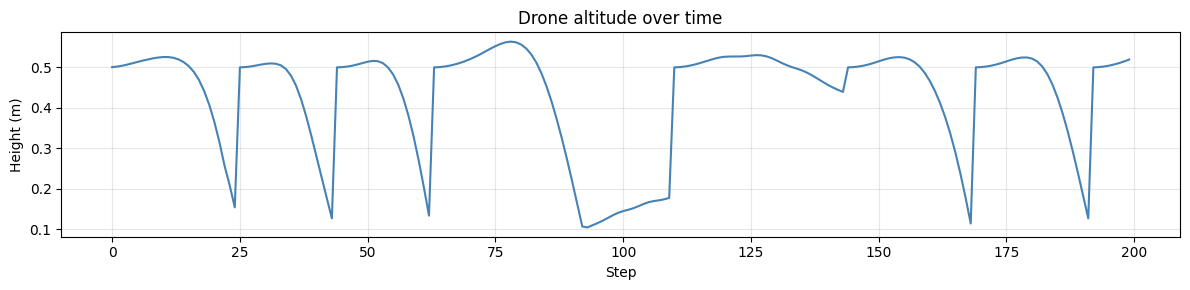

In [11]:
# Cell 9: Trajectory & rewards
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top-down XY trajectory
ax = axes[0]
env_origin = uw._env_origins[0].cpu().numpy()
local_pos = positions - env_origin
sc = ax.scatter(local_pos[:, 0], local_pos[:, 1], c=range(N_STEPS), cmap="viridis", s=8, zorder=3)
ax.plot(local_pos[0, 0], local_pos[0, 1], "g^", ms=12, label="start", zorder=5)
ax.plot(local_pos[-1, 0], local_pos[-1, 1], "rs", ms=10, label="end", zorder=5)

# Show waypoints if available
wp = uw._waypoints_w[0].cpu().numpy() - env_origin
ax.plot(wp[:, 0], wp[:, 1], "r*", ms=14, label="waypoints", zorder=4)

plt.colorbar(sc, ax=ax, label="timestep")
ax.set_xlabel("X (m, env-local)")
ax.set_ylabel("Y (m, env-local)")
ax.set_title("Drone trajectory (top-down)")
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.3)

# Reward over time
ax = axes[1]
ax.plot(rewards, color="darkorange", lw=1.5)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.fill_between(range(N_STEPS), rewards, 0, alpha=0.3, color="darkorange")
ax.set_xlabel("Step")
ax.set_ylabel("Reward")
ax.set_title(f"Per-step reward  |  Cumulative: {rewards.sum():.2f}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Height profile
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(local_pos[:, 2], color="steelblue", lw=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Height (m)")
ax.set_title("Drone altitude over time")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 10: Trajectory with Camera Thumbnails

The drone's path overlaid with actual camera images at key positions. This connects *where* the drone was to *what it saw* — you can trace its visual experience through the labyrinth.

Each thumbnail is a 64x64 grayscale frame from that point in the episode.

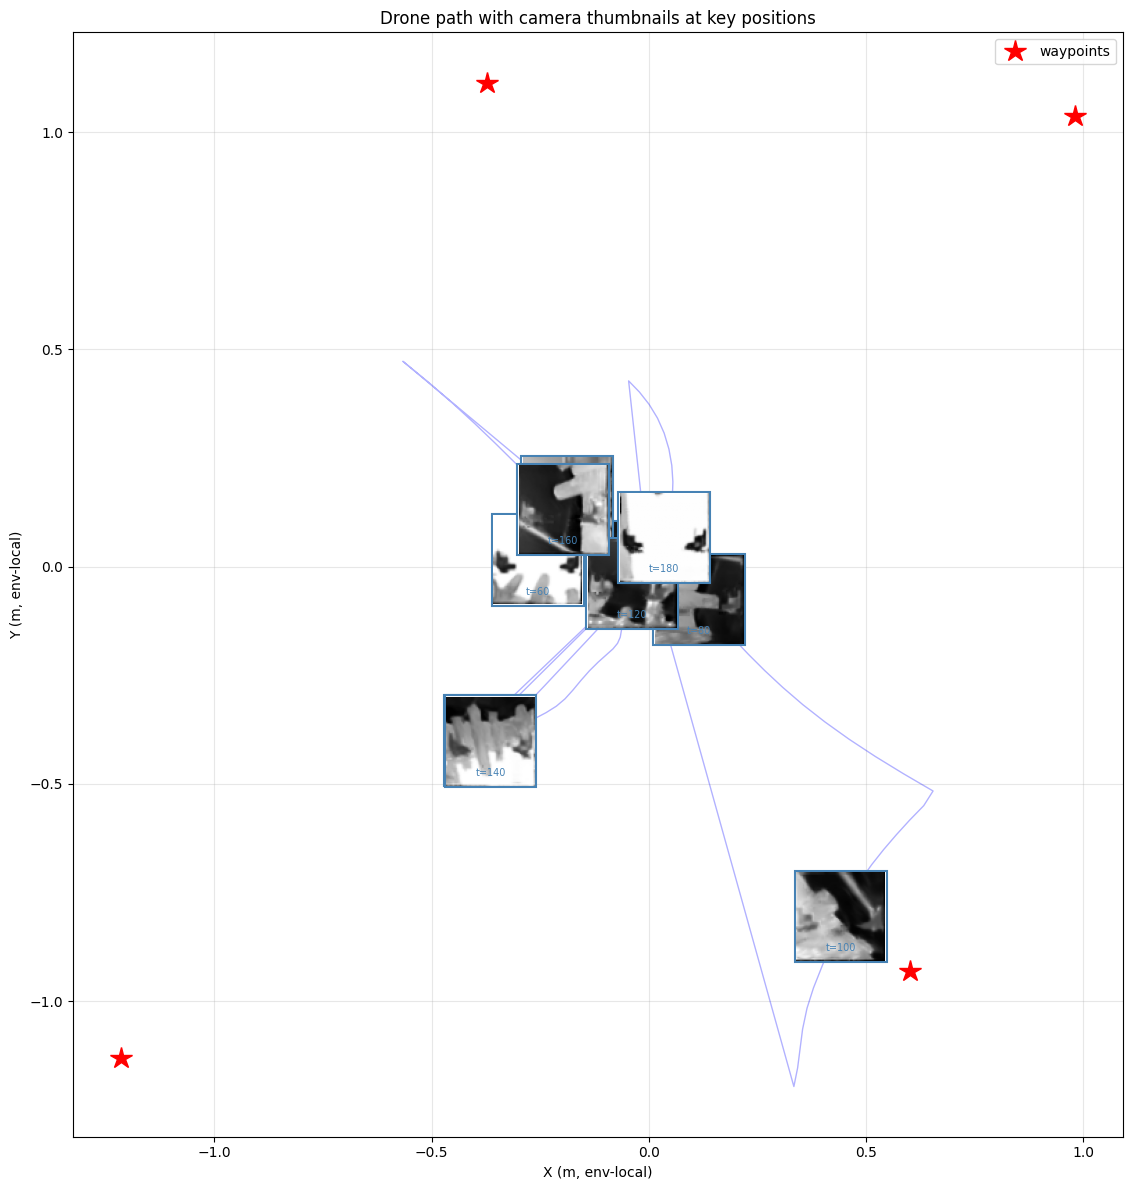

In [12]:
# Cell 10: Trajectory map with camera thumbnails
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots(figsize=(12, 12))

# Plot full trajectory
ax.plot(local_pos[:, 0], local_pos[:, 1], "b-", alpha=0.3, lw=1)
ax.plot(wp[:, 0], wp[:, 1], "r*", ms=16, label="waypoints", zorder=4)

# Place camera thumbnails at evenly spaced points
thumb_indices = list(range(0, N_STEPS, max(1, N_STEPS // 10)))
for idx in thumb_indices:
    x, y = local_pos[idx, 0], local_pos[idx, 1]
    thumb = gray_frames[idx]
    im = OffsetImage(thumb, zoom=1.0, cmap="gray")
    ab = AnnotationBbox(im, (x, y), frameon=True, pad=0.1,
                        bboxprops=dict(edgecolor="steelblue", lw=1.5))
    ax.add_artist(ab)
    ax.annotate(f"t={idx}", (x, y), textcoords="offset points",
                xytext=(0, -25), fontsize=7, ha="center", color="steelblue")

ax.set_xlabel("X (m, env-local)")
ax.set_ylabel("Y (m, env-local)")
ax.set_title("Drone path with camera thumbnails at key positions")
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cleanup

Close the gym environment to free GPU resources. 

**Do NOT call `simulation_app.close()`** — it crashes the Jupyter kernel. To re-run this notebook, just restart the kernel (Kernel > Restart) and run all cells again.

In [13]:
# Cell 11: Close gym env only (do NOT call simulation_app.close() — it kills the kernel)
env.close()
print("Environment closed. Restart kernel to re-run the notebook.")